# DDS Model – Fit Quality Analysis (OpenNeuro ds001849)

This notebook performs **fit quality inspection** for the Dual Damped Sine (DDS) model applied to TMS–EEG data from the [OpenNeuro ds001849](https://openneuro.org/datasets/ds001849) dataset. 

We focus on evaluating the consistency and adequacy of the DDS model fits across subjects, stimulation sites (M1, DLPFC, PPC), and conditions (active vs sham), using metrics such as:

- **Coefficient of determination** (R²)
- **Root Mean Square Error** (RMSE)
- **Visual inspection of residuals and waveform reconstructions**

---

### Reference implementation

- The DDS model is described in:  
  **D. Jan (2025)**. *A Dual Damped Sine (DDS) model for TMS–EEG: parametric validation against cosine similarity on OpenNeuro ds001849*. **Journal of Neuroscience Methods** (submitted).
  
- Cosine similarity is reproduced from:  
  **Freedberg et al., 2020**. *Identifying site- and stimulation-specific TMS-evoked EEG potentials using a quantitative cosine similarity metric*. *PLoS ONE*, 15(1):e0216185. [https://doi.org/10.1371/journal.pone.0216185](https://doi.org/10.1371/journal.pone.0216185)

---

### Requirements

- Python ≥3.8
- numpy, pandas, matplotlib, seaborn
- [MNE-Python](https://mne.tools/stable/index.html)
- [statsmodels](https://www.statsmodels.org/)

---

### License & Citation

This notebook is part of an open scientific pipeline. If you use or adapt this code, please cite the corresponding publication (once available) and/or contact the author:  
📧 *damian.jan@dejsl.com*



In [1]:

# =========================
# Configuration (EDIT THIS)
# =========================
from pathlib import Path

BIDS_ROOT = Path("/media/neuraldyn/Extreme SSD/GABACOG/ds001849")  # <-- EDIT to your local path

DERIV = BIDS_ROOT / "derivatives" / "dds_ds001849"
FIGS  = DERIV / "figs"
FIGS.mkdir(parents=True, exist_ok=True)

# DDS fit window (must match the runner settings)
FIT_TMIN = 0.005  # seconds
FIT_TMAX = 0.100  # seconds

GROUP_CSV = DERIV / "dds_params_group.csv"
print("BIDS_ROOT:", BIDS_ROOT)
print("DERIV:", DERIV)
print("GROUP_CSV exists:", GROUP_CSV.exists())


BIDS_ROOT: /media/neuraldyn/Extreme SSD/GABACOG/ds001849
DERIV: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849
GROUP_CSV exists: True


In [2]:

# === Quality preset (journal-neutral) + helper to save PNG/PDF/SVG ===
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

mpl.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})
plt.rcParams["figure.constrained_layout.use"] = True

# Put this once (e.g., after imports)
from pathlib import Path
import matplotlib.pyplot as plt

def save_png(path_like, dpi=600, bbox_inches="tight", pad_inches=0.01):
    p = Path(path_like)
    if p.suffix.lower() != ".png":
        p = p.with_suffix(".png")
    plt.savefig(p, dpi=dpi, bbox_inches=bbox_inches, pad_inches=pad_inches)
    print("Saved:", p)


In [3]:

# Imports and data loading
import numpy as np
import pandas as pd
from glob import glob

assert GROUP_CSV.exists(), f"Missing: {GROUP_CSV}"
params = pd.read_csv(GROUP_CSV)
print("Rows in params:", len(params))
display(params.head(5))


Rows in params: 120


,A1,gamma1,f1,phi1,A2,gamma2,f2,phi2,offset,t0,...,tmax,subject,session,task,acq,run,extension,basename,site_guess,cond_guess
0,0.000229,207.229679,75.849438,0.346039,0.001737,139.793296,4.682049,3.139983,2.268314e-06,0.005000,...,0.1,1,NaN,tmseegrest,dlpfcactive,NaN,.set,sub-01_task-tmseegrest_acq-dlpfcactive_eeg.set,dlpfc,active
1,0.000435,186.867291,4.764044,-2.747254,0.000225,243.622868,30.490240,1.070248,-3.294877e-06,0.005800,...,0.1,1,NaN,tmseegrest,dlpfcsham,NaN,.set,sub-01_task-tmseegrest_acq-dlpfcsham_eeg.set,dlpfc,sham
2,0.000033,78.468119,4.000603,-0.001137,0.000002,45.570978,38.404432,2.712119,-1.048240e-06,0.009013,...,0.1,1,NaN,tmseegrest,m1active,NaN,.set,sub-01_task-tmseegrest_acq-m1active_eeg.set,m1,active
3,0.000002,10.000000,9.225631,-0.430539,0.000014,298.372191,26.327249,0.075532,1.865348e-07,0.003562,...,0.1,1,NaN,tmseegrest,m1sham,NaN,.set,sub-01_task-tmseegrest_acq-m1sham_eeg.set,m1,sham
4,0.000547,210.502305,9.825698,-2.663962,0.000133,289.905659,80.000000,1.181234,-1.376608e-07,0.003584,...,0.1,1,NaN,tmseegrest,ppcactive,NaN,.set,sub-01_task-tmseegrest_acq-ppcactive_eeg.set,ppc,active


In [4]:

# Locate arrays saved by the runner: <basename>_times.npy, _roi.npy, _dds.npy
from pathlib import Path

def find_triples(deriv):
    triples = []
    for tpath in Path(deriv).glob("sub-*/*_times.npy"):
        base = tpath.name.replace("_times.npy","")
        parent = tpath.parent
        roi = parent / f"{base}_roi.npy"
        dds = parent / f"{base}_dds.npy"
        if roi.exists() and dds.exists():
            triples.append({"basename": base, "times": tpath, "roi": roi, "dds": dds, "parent": parent})
    return pd.DataFrame(triples)

triples = find_triples(DERIV)
print("Runs with complete arrays:", len(triples))
display(triples.head(5))

# Merge minimal metadata if available
have_key = "basename" in params.columns
if have_key:
    merged = triples.merge(params[["basename","subject","site_guess","cond_guess"]],
                           on="basename", how="left")
else:
    merged = triples.copy()
    merged["subject"] = np.nan
    merged["site_guess"] = np.nan
    merged["cond_guess"] = np.nan

display(merged.head(3))


Runs with complete arrays: 120


,basename,times,roi,dds,parent
0,sub-01_task-tmseegrest_acq-dlpfcactive_eeg.set,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...
1,sub-01_task-tmseegrest_acq-dlpfcsham_eeg.set,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...
2,sub-01_task-tmseegrest_acq-m1active_eeg.set,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...
3,sub-01_task-tmseegrest_acq-m1sham_eeg.set,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...
4,sub-01_task-tmseegrest_acq-ppcactive_eeg.set,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...


,basename,times,roi,dds,parent,subject,site_guess,cond_guess
0,sub-01_task-tmseegrest_acq-dlpfcactive_eeg.set,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,1,dlpfc,active
1,sub-01_task-tmseegrest_acq-dlpfcsham_eeg.set,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,1,dlpfc,sham
2,sub-01_task-tmseegrest_acq-m1active_eeg.set,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,/media/neuraldyn/Extreme SSD/GABACOG/ds001849/...,1,m1,active


In [5]:

# Compute RMSE and R² within [FIT_TMIN, FIT_TMAX]

def window_mask(t, tmin, tmax):
    return (t >= tmin) & (t <= tmax)

def r2_rmse(y, yhat):
    resid = y - yhat
    sse = np.sum(resid**2)
    sst = np.sum((y - y.mean())**2)
    r2 = 1.0 - (sse / sst if sst > 0 else np.nan)
    rmse = np.sqrt(np.mean(resid**2))
    return r2, rmse

rows = []
for _, r in merged.iterrows():
    t = np.load(r["times"])
    y = np.load(r["roi"])
    yhat = np.load(r["dds"])
    m = window_mask(t, FIT_TMIN, FIT_TMAX)
    if m.sum() < 10:
        continue
    r2, rmse = r2_rmse(y[m], yhat[m])
    rows.append({
        "basename": r["basename"],
        "subject": r["subject"],
        "site": r["site_guess"],
        "cond": r["cond_guess"],
        "R2": r2,
        "RMSE": rmse,
    })

metrics = pd.DataFrame(rows)
print("Computed metrics for runs:", len(metrics))
display(metrics.head(10))

out_csv = DERIV / "dds_fit_metrics.csv"
metrics.to_csv(out_csv, index=False)
print("Saved:", out_csv)


Computed metrics for runs: 120


,basename,subject,site,cond,R2,RMSE
0,sub-01_task-tmseegrest_acq-dlpfcactive_eeg.set,1,dlpfc,active,0.984293,5.810074e-06
1,sub-01_task-tmseegrest_acq-dlpfcsham_eeg.set,1,dlpfc,sham,0.847310,5.105476e-06
2,sub-01_task-tmseegrest_acq-m1active_eeg.set,1,m1,active,0.933208,3.468363e-07
3,sub-01_task-tmseegrest_acq-m1sham_eeg.set,1,m1,sham,0.955441,1.784644e-07
4,sub-01_task-tmseegrest_acq-ppcactive_eeg.set,1,ppc,active,0.999202,1.055756e-06
5,sub-01_task-tmseegrest_acq-ppcsham_eeg.set,1,ppc,sham,0.950597,6.561468e-07
6,sub-02_task-tmseegrest_acq-dlpfcactive_eeg.set,2,dlpfc,active,0.952002,5.515740e-06
7,sub-02_task-tmseegrest_acq-dlpfcsham_eeg.set,2,dlpfc,sham,0.937134,1.061158e-06
8,sub-02_task-tmseegrest_acq-m1active_eeg.set,2,m1,active,0.887407,3.915896e-07
9,sub-02_task-tmseegrest_acq-m1sham_eeg.set,2,m1,sham,0.914872,2.214506e-07


Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/dds_fit_metrics.csv


In [6]:

# Summary by site × condition
summ = (metrics.groupby(["site","cond"]).agg(
    n=("R2","size"),
    R2_mean=("R2","mean"),
    R2_median=("R2","median"),
    RMSE_mean=("RMSE","mean"),
    RMSE_median=("RMSE","median"),
).reset_index())
display(summ)

out_csv2 = DERIV / "dds_fit_metrics_by_site_cond.csv"
summ.to_csv(out_csv2, index=False)
print("Saved:", out_csv2)


,site,cond,n,R2_mean,R2_median,RMSE_mean,RMSE_median
0,dlpfc,active,20,0.942378,0.984380,1.362426e-05,8.701429e-06
1,dlpfc,sham,20,0.930718,0.987549,3.407023e-06,2.568615e-06
2,m1,active,20,0.925654,0.955220,6.660938e-07,4.684358e-07
3,m1,sham,20,0.836193,0.914262,3.874003e-07,3.425900e-07
4,ppc,active,20,0.789054,0.948016,9.019018e-07,6.581886e-07
5,ppc,sham,20,0.822079,0.933067,4.423535e-07,3.548946e-07


Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/dds_fit_metrics_by_site_cond.csv


Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/figs/hist_R2_all_runs.png


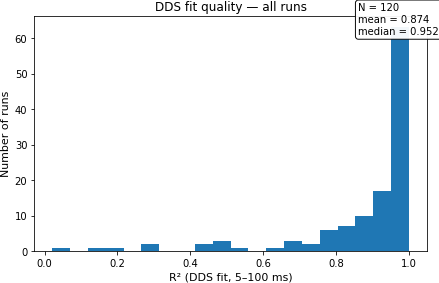

In [7]:

import numpy as np
import matplotlib.pyplot as plt

r2vals = metrics["R2"].dropna().values
N = r2vals.size; mean_r2 = np.mean(r2vals); median_r2 = np.median(r2vals)

fig = plt.figure(figsize=(6,4), constrained_layout=False)   # disable constrained_layout here
ax = plt.gca()
ax.hist(r2vals, bins=20)
ax.set_xlabel("R² (DDS fit, 5–100 ms)")
ax.set_ylabel("Number of runs")
ax.set_title("DDS fit quality — all runs")

# reserva margen derecha para la “tarjeta”
fig.subplots_adjust(right=0.82)
fig.text(0.835, 0.98,
         f"N = {N}\nmean = {mean_r2:.3f}\nmedian = {median_r2:.3f}",
         ha="left", va="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.95))
save_png(FIGS / "hist_R2_all_runs")
plt.show()


In [8]:

# Utilities to fetch DDS parameters per basename and format the annotation block
import numpy as np
import pandas as pd

PARAM_COLS = ["A1","f1","gamma1","A2","f2","gamma2"]

def get_params_for_basename(basename: str, params_df: pd.DataFrame):
    if "basename" not in params_df.columns:
        return None
    row = params_df[params_df["basename"] == basename]
    if row.empty:
        return None
    d = row.iloc[0].to_dict()
    return {k: d.get(k, np.nan) for k in PARAM_COLS}

def format_param_block(param_dict: dict, R2: float, RMSE: float) -> str:
    if not param_dict:
        return f"R² = {R2:.3f}   RMSE = {RMSE:.3g}"
    g1, g2 = "γ1", "γ2"
    txt = (
        f"A1 = {param_dict.get('A1', np.nan):.3g}   "
        f"f1 = {param_dict.get('f1', np.nan):.3g} Hz   "
        f"{g1} = {param_dict.get('gamma1', np.nan):.3g} s⁻¹\n"
        f"A2 = {param_dict.get('A2', np.nan):.3g}   "
        f"f2 = {param_dict.get('f2', np.nan):.3g} Hz   "
        f"{g2} = {param_dict.get('gamma2', np.nan):.3g} s⁻¹\n"
        f"R² = {R2:.3f}   RMSE = {RMSE:.3g}"
    )
    return txt


Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/figs/overlay_dlpfc_active_sub-14.png


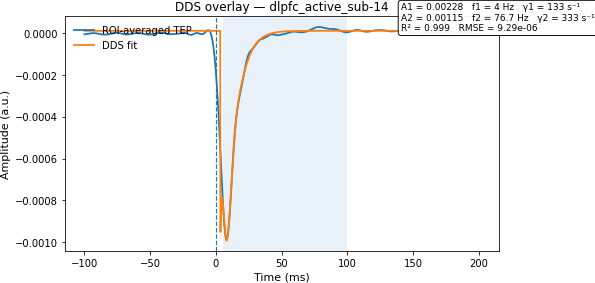

Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/figs/overlay_dlpfc_sham_sub-4.png


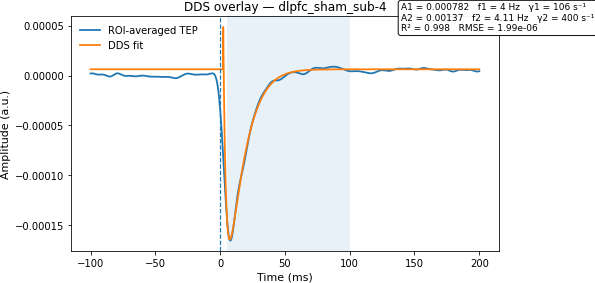

Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/figs/overlay_m1_active_sub-3.png


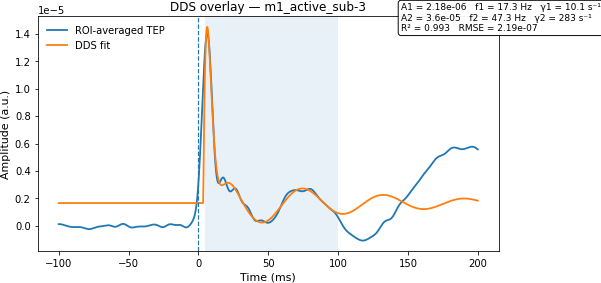

Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/figs/overlay_m1_sham_sub-11.png


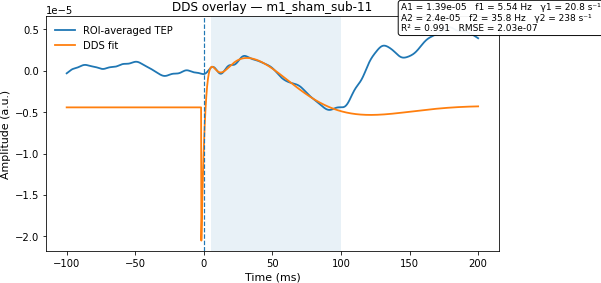

Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/figs/overlay_ppc_active_sub-1.png


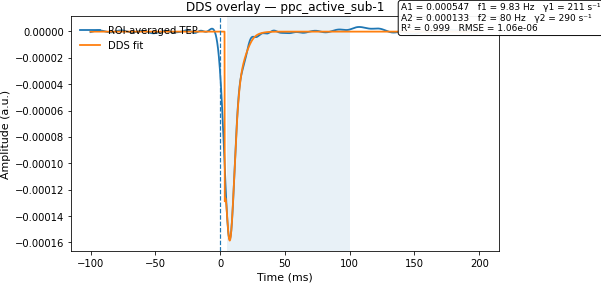

Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/figs/overlay_ppc_sham_sub-12.png


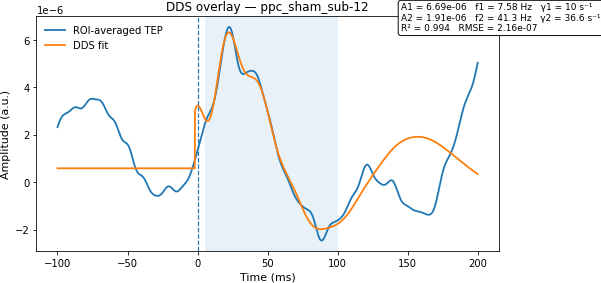

In [11]:

# Annotated overlays: add DDS parameters + R² / RMSE in a corner box
def best_example(df, site, cond):
    sub = df[(df["site"]==site) & (df["cond"]==cond)]
    if sub.empty:
        return None
    return sub.sort_values("R2", ascending=False).iloc[0]

import numpy as np
import matplotlib.pyplot as plt

def plot_overlay_sidecard(t, y, yhat, tmin, tmax, title_suffix, param_block, outdir):
    # Crea figura SIN constrained_layout para poder controlar márgenes
    fig = plt.figure(figsize=(7,4), constrained_layout=False)
    ax = plt.gca()
    ax.plot(t*1000, y, label="ROI-averaged TEP")
    ax.plot(t*1000, yhat, label="DDS fit")
    ax.axvline(0, linestyle="--", linewidth=1.2)
    ax.axvspan(tmin*1000, tmax*1000, alpha=0.10)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.set_title(f"DDS overlay — {title_suffix}")
    ax.legend(loc="upper left", frameon=False)

    # Deja una franja a la derecha y coloca la “tarjeta” allí
    fig.subplots_adjust(right=0.78)  # ~22% para la tarjeta
    fig.text(0.80, 0.98, param_block,
             ha="left", va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.95),
             fontsize=9)

    save_png(outdir / f"overlay_{title_suffix.replace(' ', '_')}")
    plt.show()

for site in ["dlpfc","m1","ppc"]:
    for cond in ["active","sham"]:
        pick = best_example(metrics, site, cond)
        if pick is None:
            continue
        row = merged[merged["basename"]==pick["basename"]].iloc[0]
        t = np.load(row["times"]); y = np.load(row["roi"]); yhat = np.load(row["dds"])
        pvals = get_params_for_basename(pick["basename"], params)
        pblock = format_param_block(pvals, R2=float(pick["R2"]), RMSE=float(pick["RMSE"]))
        suffix = f"{site}_{cond}_sub-{pick['subject']}"
        plot_overlay_sidecard(t, y, yhat, FIT_TMIN, FIT_TMAX, suffix, pblock, FIGS)


In [18]:
print(metrics.sort_values("R2", ascending=False).iloc[1])

basename    sub-14_task-tmseegrest_acq-dlpfcactive_eeg.set
subject                                                 14
site                                                 dlpfc
cond                                                active
R2                                                0.998679
RMSE                                              0.000009
Name: 78, dtype: object


Saved: /media/neuraldyn/Extreme SSD/GABACOG/ds001849/derivatives/dds_ds001849/figs/residuals_best_14.png


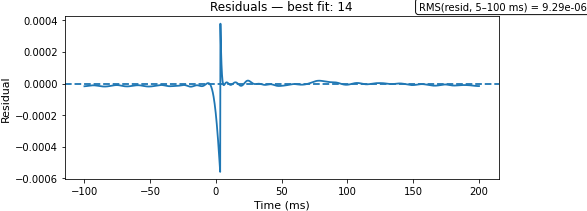

In [20]:

if not metrics.empty:
    best = metrics.sort_values("R2", ascending=False).iloc[1]
    row = merged[merged["basename"]==best["basename"]].iloc[0]
    t = np.load(row["times"]); y = np.load(row["roi"]); yhat = np.load(row["dds"])
    resid = y - yhat
    rms_resid = float(np.sqrt(np.mean(resid[(t>=FIT_TMIN)&(t<=FIT_TMAX)]**2)))

    fig = plt.figure(figsize=(7,3), constrained_layout=False)
    ax = plt.gca()
    ax.plot(t*1000, resid)
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Residual")
    ax.set_title(f"Residuals — best fit: {best['subject']}")

    fig.subplots_adjust(right=0.82)
    fig.text(0.835, 0.98, f"RMS(resid, {int(FIT_TMIN*1000)}–{int(FIT_TMAX*1000)} ms) = {rms_resid:.3g}",
             ha="left", va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.95))
    save_png(FIGS / f"residuals_best_{best['subject']}")
    plt.show()
